# YAP476
Instacart Multilevel Mining
Topic 5: Multi-Level & Multi-Dim. Mining
Dataset: https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis 

In [1]:
#imports & setup & data loading & merging
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import networkx as nx

plt.style.use('seaborn-v0_8-muted')
sns.set_theme(style="whitegrid")

products = pd.read_csv('products.csv')
aisles = pd.read_csv('aisles.csv')
departments = pd.read_csv('departments.csv')
order_products = pd.read_csv('order_products__prior.csv', nrows = 2e6)

df_merged = order_products.merge(products, on='product_id', how='left')
df_merged = df_merged.merge(aisles, on='aisle_id', how='left')
df_merged = df_merged.merge(departments, on='department_id', how='left')

print("shape:", df_merged.shape)
print("\nattributes:", df_merged.columns.tolist())
print("\nbasic stats for numeric columns:")
display(df_merged.describe())

shape: (2000000, 9)

attributes: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department']

basic stats for numeric columns:


,order_id,product_id,add_to_cart_order,reordered,aisle_id,department_id
count,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,1.055277e+05,2.557660e+04,8.361097e+00,5.897020e-01,7.119376e+01,9.924762e+00
std,6.084514e+04,1.409626e+04,7.148741e+00,4.918879e-01,3.820814e+01,6.283171e+00
min,2.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
25%,5.288300e+04,1.351700e+04,3.000000e+00,0.000000e+00,3.100000e+01,4.000000e+00
50%,1.056290e+05,2.525600e+04,6.000000e+00,1.000000e+00,8.300000e+01,9.000000e+00
75%,1.581420e+05,3.791900e+04,1.100000e+01,1.000000e+00,1.070000e+02,1.600000e+01
max,2.108670e+05,4.968800e+04,1.270000e+02,1.000000e+00,1.340000e+02,2.100000e+01


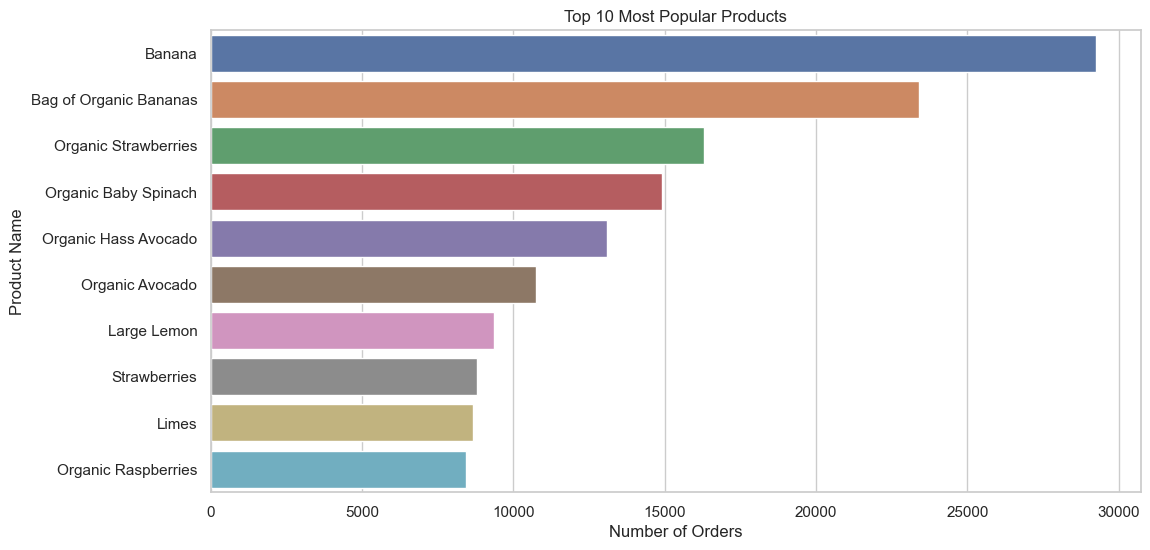

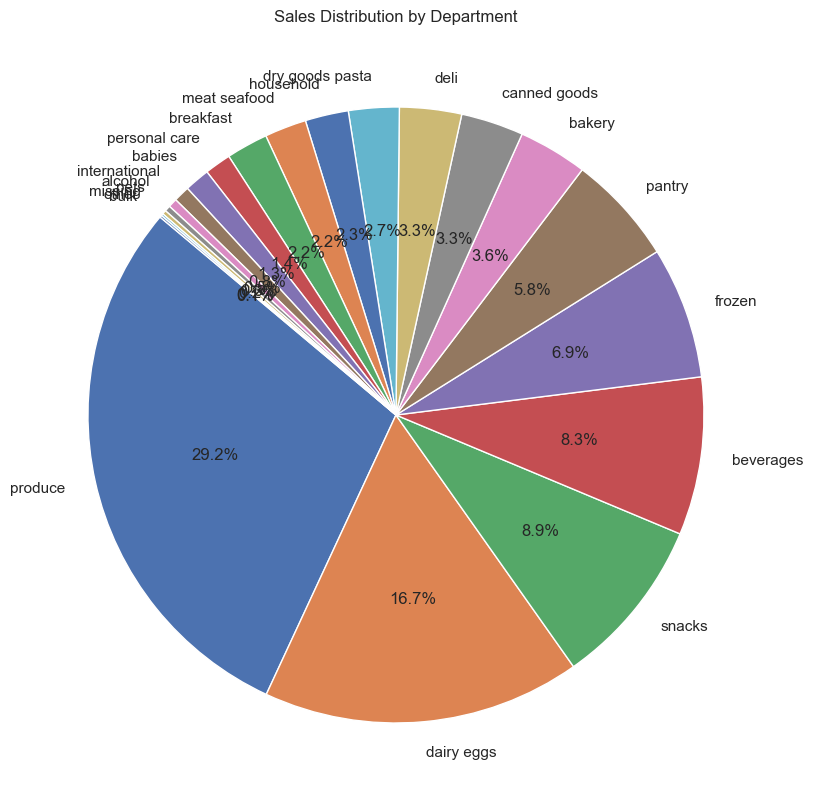

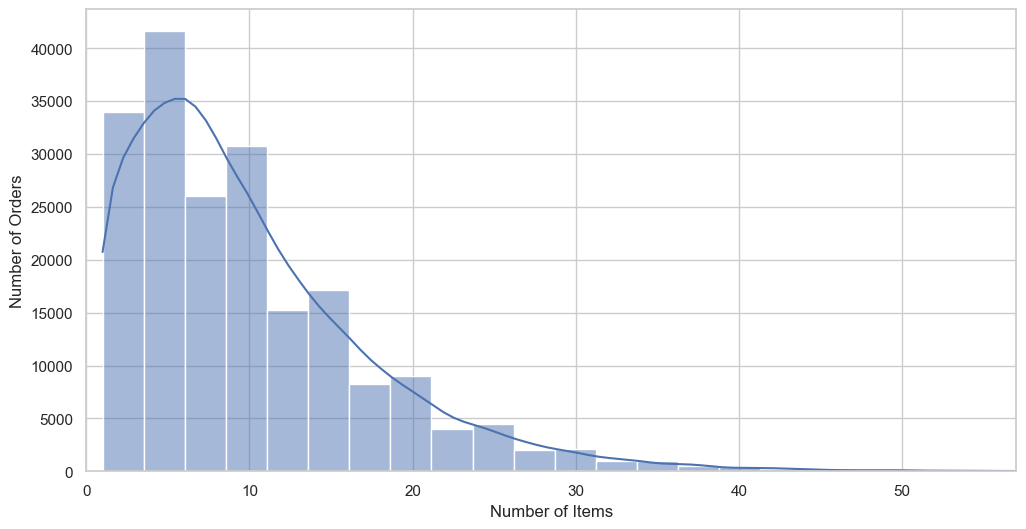

In [2]:
#prepping 'understanding data' section in report
plt.figure(figsize=(12, 6))
top_10_products = df_merged['product_name'].value_counts().head(10)
sns.barplot(
    x=top_10_products.values,
    y=top_10_products.index,
    hue=top_10_products.index,
    #palette=''
    legend=False
)
plt.title('Top 10 Most Popular Products')
plt.xlabel('Number of Orders')
plt.ylabel('Product Name')
plt.show()

plt.figure(figsize=(10, 10))
dept_counts = df_merged['department'].value_counts()
plt.pie(
    dept_counts,
    labels=dept_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    #colors=sns.color_palette('')
)
plt.title('Sales Distribution by Department')
plt.show()

plt.figure(figsize=(12, 6))
basket_size = df_merged.groupby('order_id').size()
sns.histplot(
    basket_size,
    bins=50,
    kde=True,
    #color=''
)
plt.xlabel('Number of Items')
plt.ylabel('Number of Orders')
plt.xlim(0, 57)
plt.show()

In [3]:
#transactions prep
transactions_dept = df_merged.groupby('order_id')['department'].apply(list).values.tolist()
transactions_aisle = df_merged.groupby('order_id')['aisle'].apply(list).values.tolist()
transactions_prod = df_merged.groupby('order_id')['product_name'].apply(list).values.tolist()

te = TransactionEncoder() #one hot encoding (?)
te_ary_dept = te.fit(transactions_dept).transform(transactions_dept)
df_dept = pd.DataFrame(te_ary_dept, columns=te.columns_)
te_ary_prod = te.fit(transactions_prod).transform(transactions_prod, sparse=True)
df_prod = pd.DataFrame.sparse.from_spmatrix(te_ary_prod, columns=te.columns_)
te_ary_aisle = te.fit(transactions_aisle).transform(transactions_aisle)
df_aisle = pd.DataFrame(te_ary_aisle, columns=te.columns_)

print("dept DF shape:", df_dept.shape, ",prod DF shape:", df_prod.shape, ",aisle DF shape:", df_aisle.shape)

dept DF shape: (198086, 21) ,prod DF shape: (198086, 40477) ,aisle DF shape: (198086, 134)


In [4]:
min_sup = 0.02
print("running algos w minsup:", min_sup)

# apriori
start_time = time.time()
frequent_itemsets_apriori = apriori(df_dept, min_support=min_sup, use_colnames=True)
apriori_time = time.time() - start_time
print(f"apriori runtime: {apriori_time:.4f} s")

# fpg
start_time = time.time()
frequent_itemsets_fp = fpgrowth(df_dept, min_support=min_sup, use_colnames=True)
fp_time = time.time() - start_time
print(f"fpg runtime: {fp_time:.4f} s")

frequent_dept = fpgrowth(df_dept, min_support=0.01, use_colnames=True)
rules_dept = association_rules(frequent_dept, metric="lift", min_threshold=1.0)
frequent_aisle = fpgrowth(df_aisle, min_support=0.008, use_colnames=True)
rules_aisle = association_rules(frequent_aisle, metric="lift", min_threshold=1.1)
frequent_prod = fpgrowth(df_prod, min_support=0.005, use_colnames=True)
rules_prod = association_rules(frequent_prod, metric="lift", min_threshold=1.2)

running algos w minsup: 0.02
apriori runtime: 1.1507 s
fpg runtime: 0.8269 s


In [ ]:
# rule mining
rules_dept = association_rules(frequent_itemsets_fp, metric="lift", min_threshold=1.0)
rules_dept = rules_dept.sort_values(by='confidence', ascending=False)
rules_dept['kulczynski'] = (rules_dept['support'] / rules_dept['antecedent support'] + 
                            rules_dept['support'] / rules_dept['consequent support']) / 2

rules_dept['ir'] = np.abs(rules_dept['antecedent support'] - rules_dept['consequent support']) / \
                   (rules_dept['antecedent support'] + rules_dept['consequent support'] - rules_dept['support'])


frequent_itemsets_prod = fpgrowth(df_prod, min_support=0.005, use_colnames=True)
rules_prod = association_rules(frequent_itemsets_prod, metric="lift", min_threshold=1.2)
rules_prod = rules_prod.sort_values(by='confidence', ascending=False)


rules_fmt = rules_dept.copy()
rules_fmt['antecedents'] = rules_fmt['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_fmt['consequents'] = rules_fmt['consequents'].apply(lambda x: ', '.join(list(x)))
rules_fmt = rules_fmt.round({'support': 4, 'confidence': 4, 'lift': 4, 'kulczynski': 4})
print("\n--- dept top 5 rules ---")
display(rules_fmt[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())


--- dept top 5 rules ---


,antecedents,consequents,support,confidence,lift
21979,"pantry, canned goods, deli, snacks, dairy eggs",produce,0.0230,0.9540,1.2749
22101,"frozen, pantry, canned goods, deli, dairy eggs",produce,0.0216,0.9537,1.2746
6209,"frozen, breakfast, beverages, produce, bakery",dairy eggs,0.0202,0.9514,1.4052
22772,"canned goods, deli, snacks, dairy eggs, bakery",produce,0.0206,0.9513,1.2714
5941,"pantry, breakfast, snacks, produce, bakery",dairy eggs,0.0220,0.9511,1.4049


In [6]:
mapping = df_merged[['product_name', 'aisle', 'department']].drop_duplicates().set_index('product_name')

def check_redundancy(low_rule, high_rules, mapping_col):
    ant_high = frozenset({mapping.loc[item, mapping_col] for item in low_rule['antecedents']})
    cons_high = frozenset({mapping.loc[item, mapping_col] for item in low_rule['consequents']})
    match = high_rules[(high_rules['antecedents'] == ant_high) & (high_rules['consequents'] == cons_high)]
    if not match.empty:
        high_conf = match.iloc[0]['confidence']
        if abs(low_rule['confidence'] - high_conf) < 0.1:
            return True
    return False

rules_prod['is_redundant'] = rules_prod.apply(lambda x: check_redundancy(x, rules_aisle, 'aisle'), axis=1)
interesting_rules = rules_prod[rules_prod['is_redundant'] == False].copy()

print(f"total rules: {len(rules_prod)}")
print(f"non redundant rules: {len(interesting_rules)}")

total rules: 144
non redundant rules: 142


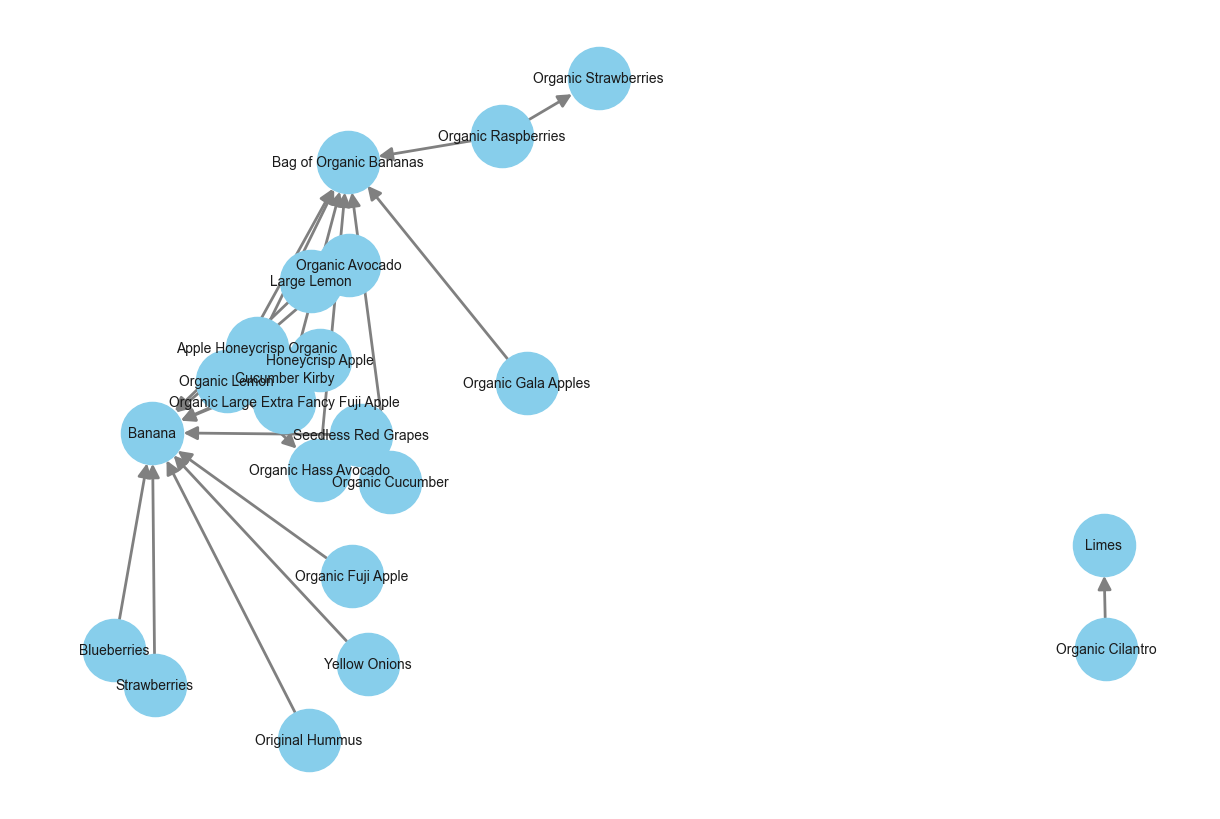

In [7]:
def plot_rules_network(rules_df, num_rules=20):
    G = nx.DiGraph()
    top_rules = rules_df.sort_values('confidence', ascending=False).head(num_rules)
    
    for _, row in top_rules.iterrows():
        ant = ', '.join(list(row['antecedents']))
        cons = ', '.join(list(row['consequents']))
        G.add_edge(ant, cons, weight=row['lift'])

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=0.5)
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2000, 
            edge_color='gray', font_size=10, width=2, arrowsize=20)
    plt.show()

plot_rules_network(interesting_rules)